In [4]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix,classification_report

In [7]:
df = pd.read_csv('vitamin_deficiency_disease_dataset_cleaned.csv')
df

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,vitamin_a_percent_rda,vitamin_c_percent_rda,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_dry_skin
0,79,Male,24.8,Former,Never,Active,Vegetarian,High,119.1,147.3,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,85.7,57.5,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,48.3,152.1,...,1,0,0,0,0,0,0,0,Healthy,1
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,75.8,51.0,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,Never,Moderate,Vegetarian,Moderate,93.3,111.5,...,0,0,0,0,0,0,0,0,Healthy,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,25,Female,21.6,Former,Heavy,Active,Pescatarian,Moderate,41.4,66.1,...,1,0,0,0,0,0,0,0,Healthy,0
3996,50,Male,29.5,Former,Moderate,Sedentary,Vegetarian,Low,146.3,113.0,...,0,0,0,0,0,0,0,0,Healthy,0
3997,34,Female,24.8,Never,Never,Active,Pescatarian,Moderate,77.0,39.8,...,0,1,0,0,0,1,1,0,Anemia,0
3998,39,Female,26.9,Former,Heavy,Active,Omnivore,High,41.1,71.2,...,1,0,0,0,0,0,0,0,Anemia,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      4000 non-null   int64  
 1   gender                   4000 non-null   object 
 2   bmi                      4000 non-null   float64
 3   smoking_status           4000 non-null   object 
 4   alcohol_consumption      4000 non-null   object 
 5   exercise_level           4000 non-null   object 
 6   diet_type                4000 non-null   object 
 7   sun_exposure             4000 non-null   object 
 8   vitamin_a_percent_rda    4000 non-null   float64
 9   vitamin_c_percent_rda    4000 non-null   float64
 10  vitamin_d_percent_rda    4000 non-null   float64
 11  vitamin_e_percent_rda    4000 non-null   float64
 12  vitamin_b12_percent_rda  4000 non-null   float64
 13  folate_percent_rda       4000 non-null   float64
 14  calcium_percent_rda     

In [4]:
df.isnull().sum()

age                        0
gender                     0
bmi                        0
smoking_status             0
alcohol_consumption        0
exercise_level             0
diet_type                  0
sun_exposure               0
vitamin_a_percent_rda      0
vitamin_c_percent_rda      0
vitamin_d_percent_rda      0
vitamin_e_percent_rda      0
vitamin_b12_percent_rda    0
folate_percent_rda         0
calcium_percent_rda        0
iron_percent_rda           0
hemoglobin_g_dl            0
serum_vitamin_d_ng_ml      0
serum_vitamin_b12_pg_ml    0
serum_folate_ng_ml         0
has_night_blindness        0
has_fatigue                0
has_bleeding_gums          0
has_bone_pain              0
has_muscle_weakness        0
has_numbness_tingling      0
has_memory_problems        0
has_pale_skin              0
disease_diagnosis          0
has_dry_skin               0
dtype: int64

In [5]:
sns.set_palette('Set2')
sns.set_style('whitegrid')

<Figure size 3000x2000 with 0 Axes>

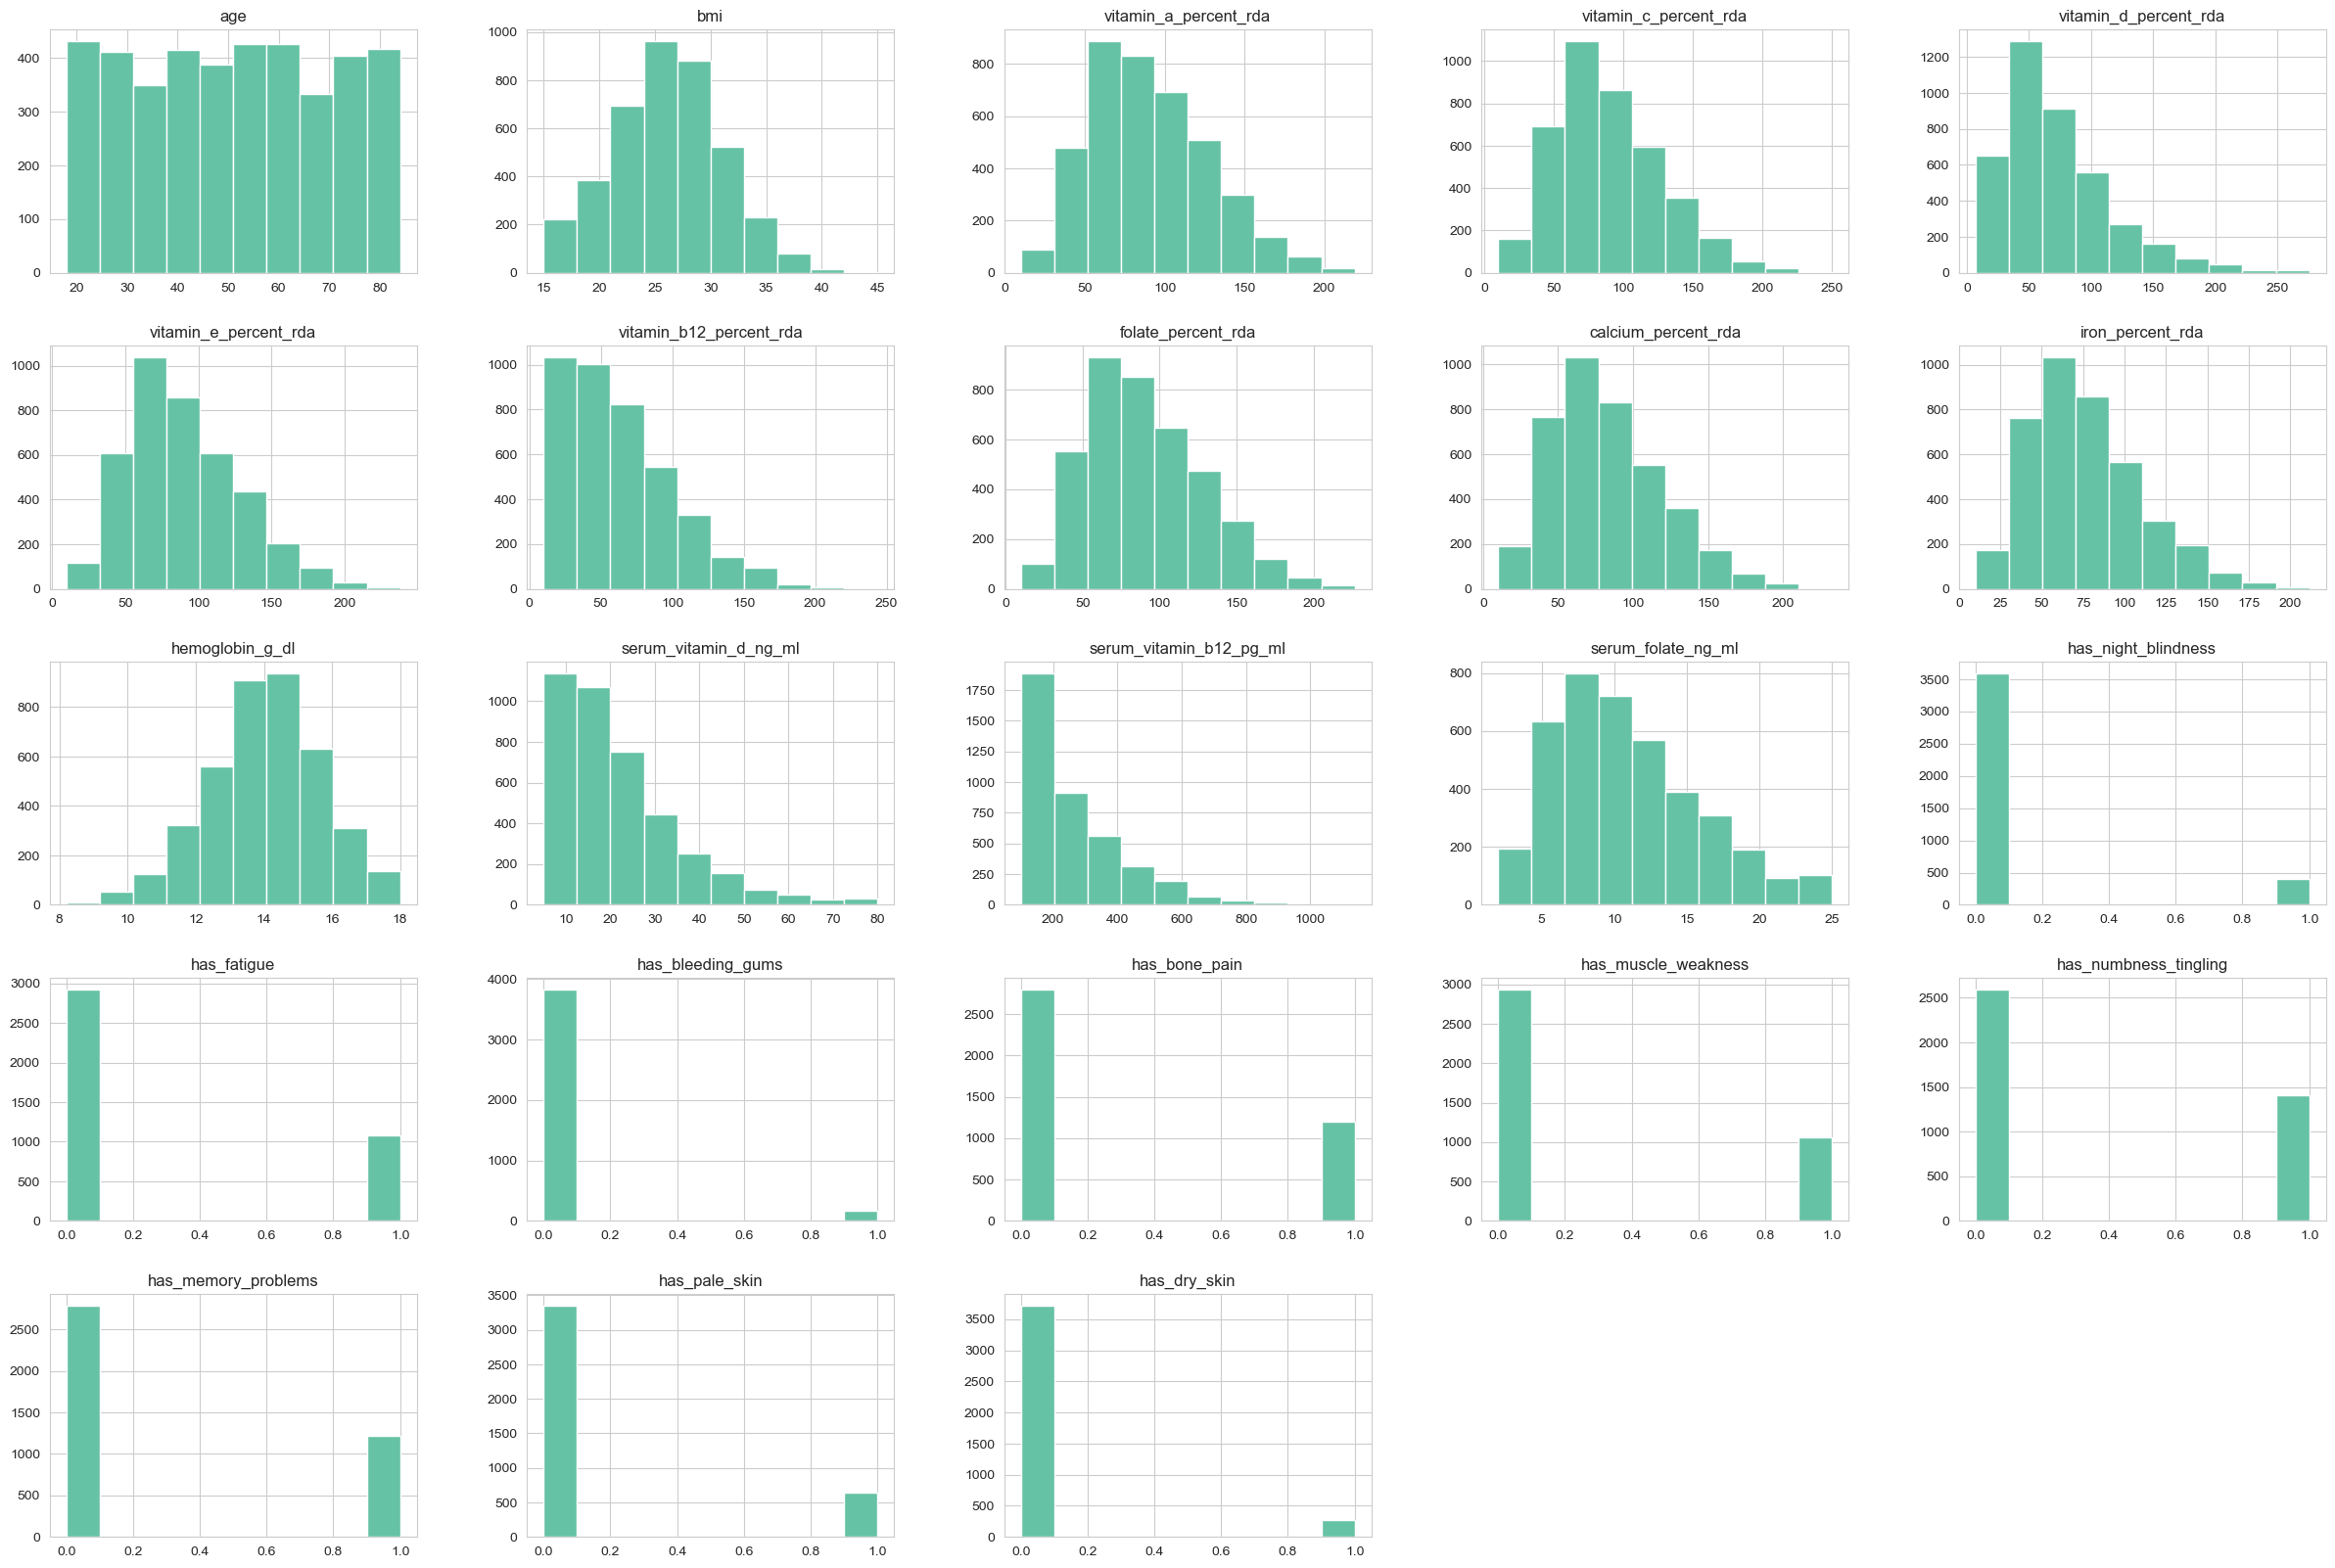

In [6]:
plt.figure(figsize=(30,20))
df.hist(figsize=(30,20))
plt.show()

In [7]:
num= df.select_dtypes(include=np.number)
corr = num.corr()

<Axes: >

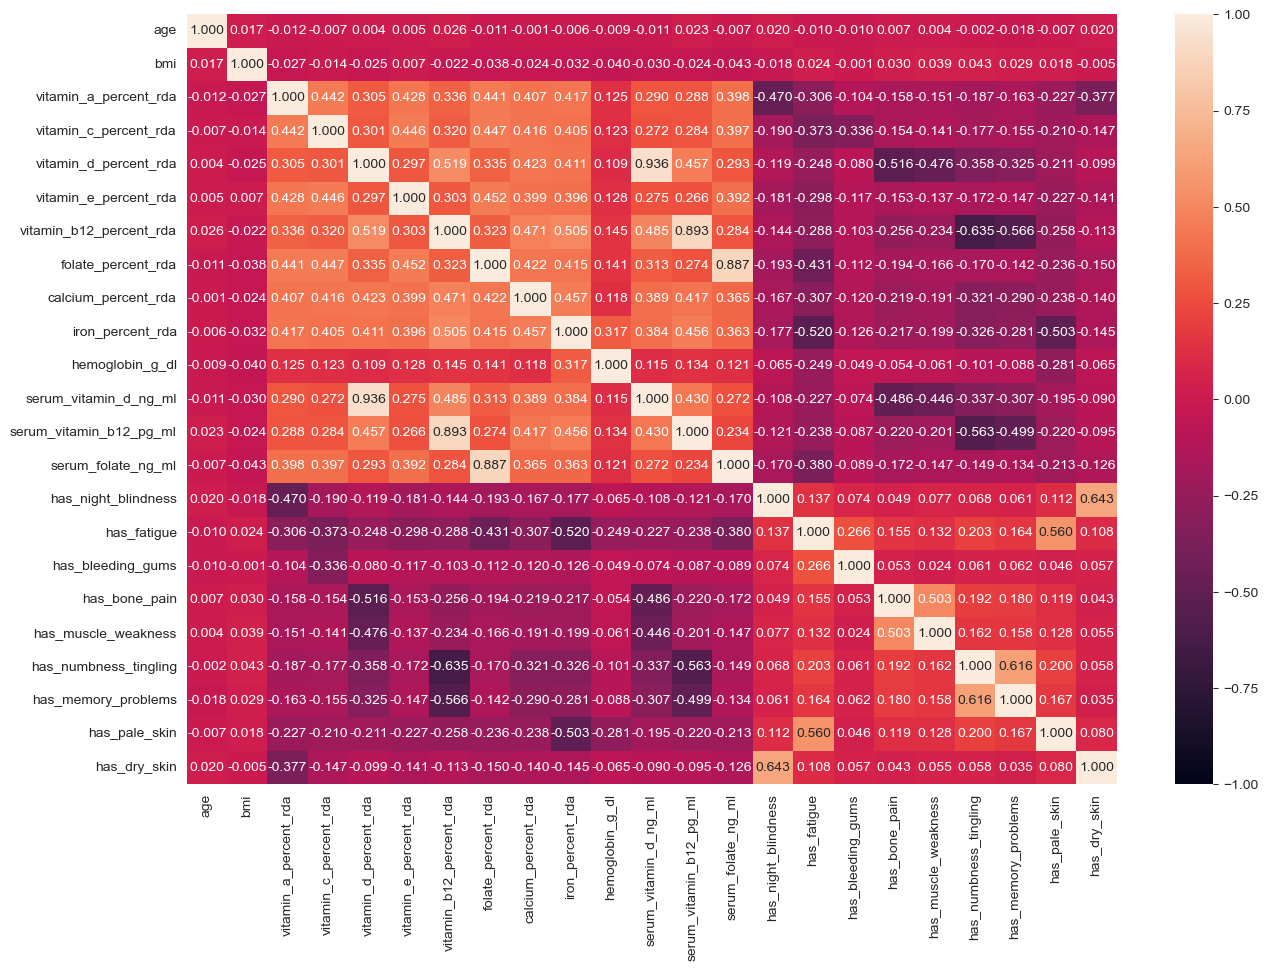

In [8]:
plt.figure(figsize=(15,10))
sns.heatmap(data=corr, annot=True,fmt=".3f",vmin=-1, vmax=1)

In [9]:
y = df.disease_diagnosis
y

0                    Healthy
1       Rickets_Osteomalacia
2                    Healthy
3                     Anemia
4                    Healthy
                ...         
3995                 Healthy
3996                 Healthy
3997                  Anemia
3998                  Anemia
3999                  Anemia
Name: disease_diagnosis, Length: 4000, dtype: object

In [10]:
X = df.drop(columns = ['disease_diagnosis'])
X

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,vitamin_a_percent_rda,vitamin_c_percent_rda,...,serum_folate_ng_ml,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,has_dry_skin
0,79,Male,24.8,Former,Never,Active,Vegetarian,High,119.1,147.3,...,23.3,0,0,0,0,0,0,0,0,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,85.7,57.5,...,5.3,0,0,0,1,0,0,0,0,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,48.3,152.1,...,16.3,1,0,0,0,0,0,0,0,1
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,75.8,51.0,...,9.2,0,0,0,0,0,1,1,0,0
4,63,Male,29.6,Never,Never,Moderate,Vegetarian,Moderate,93.3,111.5,...,13.4,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,25,Female,21.6,Former,Heavy,Active,Pescatarian,Moderate,41.4,66.1,...,9.2,1,0,0,0,0,0,0,0,0
3996,50,Male,29.5,Former,Moderate,Sedentary,Vegetarian,Low,146.3,113.0,...,15.0,0,0,0,0,0,0,0,0,0
3997,34,Female,24.8,Never,Never,Active,Pescatarian,Moderate,77.0,39.8,...,4.8,0,1,0,0,0,1,1,0,0
3998,39,Female,26.9,Former,Heavy,Active,Omnivore,High,41.1,71.2,...,6.1,1,0,0,0,0,0,0,0,1


In [11]:
le = LabelEncoder()
le.fit(y)

LabelEncoder()

In [12]:
y_classes = le.classes_

In [13]:
y = le.transform(y)
y

array([1, 3, 1, ..., 0, 0, 0], shape=(4000,))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify = y)

In [15]:
cat = X_train.select_dtypes(include=object)

In [16]:
cat

,gender,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure
2618,Female,Never,Heavy,Sedentary,Vegetarian,Moderate
3156,Male,Current,Never,Light,Pescatarian,Moderate
3849,Female,Former,Moderate,Sedentary,Omnivore,High
193,Male,Former,Moderate,Active,Pescatarian,Low
550,Female,Current,Moderate,Active,Pescatarian,Moderate
...,...,...,...,...,...,...
2037,Male,Never,Heavy,Moderate,Vegetarian,High
1334,Female,Former,Heavy,Light,Pescatarian,Low
3916,Male,Current,Heavy,Sedentary,Pescatarian,High
799,Male,Former,Heavy,Moderate,Vegan,Low


In [17]:
num = X_train.select_dtypes(include=np.number)

In [18]:
num

,age,bmi,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,...,serum_folate_ng_ml,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,has_dry_skin
2618,65,27.7,80.4,90.0,87.70,47.4,76.7,95.0,128.8,91.0,...,12.4,0,0,0,0,0,0,0,0,0
3156,25,31.2,114.9,94.0,86.40,111.0,42.3,102.0,80.9,75.9,...,14.4,0,0,0,0,0,1,1,0,0
3849,46,15.0,200.4,144.5,143.26,133.2,120.1,109.3,118.0,137.0,...,11.0,0,0,0,0,0,0,0,0,0
193,50,27.0,40.1,43.9,70.00,53.7,54.0,68.1,50.6,54.1,...,8.7,1,0,0,1,1,0,0,0,1
550,27,31.2,51.2,74.9,104.10,54.0,28.1,82.6,69.7,37.6,...,10.3,0,0,0,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2037,24,23.9,110.0,114.7,118.17,134.5,72.2,70.9,131.9,78.1,...,8.9,0,0,0,0,0,0,0,0,0
1334,50,33.4,119.0,69.5,64.68,92.8,74.4,120.7,121.9,91.1,...,9.3,0,0,0,0,1,0,0,0,0
3916,39,27.3,108.8,167.0,183.30,114.6,97.2,96.1,153.3,85.6,...,12.9,0,0,0,0,0,0,0,0,0
799,73,26.6,60.5,56.0,22.19,64.7,15.0,67.4,46.6,47.1,...,9.0,0,0,0,1,1,1,1,0,0


In [19]:
encoder = OneHotEncoder(sparse_output=False)

In [20]:
scaler = StandardScaler()

In [21]:
cat_pipe = make_pipeline(encoder, scaler)

In [22]:
num_pipe = make_pipeline(scaler)

In [23]:
preprocess = make_column_transformer(
    (cat_pipe, make_column_selector(dtype_include=object)),
    (num_pipe, make_column_selector(dtype_include=np.number))
    
)

In [24]:
preprocess.fit(X_train)

,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [25]:
X_train_pro = preprocess.transform(X_train)
X_train_pro = pd.DataFrame(X_train_pro)

In [26]:
Lr = LogisticRegression()
tr = DecisionTreeClassifier(random_state=17)
knn = KNeighborsClassifier()
rc = RandomForestClassifier()

In [27]:
title = 'CLASSIFICATION REPORT FOR'

****************************CLASSIFICATION REPORT FOR LOGISTICREGRESSION**************************** 
                      precision    recall  f1-score   support

              Anemia       0.93      0.87      0.90       996
             Healthy       0.92      0.97      0.95      1207
     Night_Blindness       0.70      0.58      0.63        98
Rickets_Osteomalacia       0.92      0.93      0.92       823
              Scurvy       0.55      0.55      0.55        76

            accuracy                           0.91      3200
           macro avg       0.80      0.78      0.79      3200
        weighted avg       0.91      0.91      0.91      3200



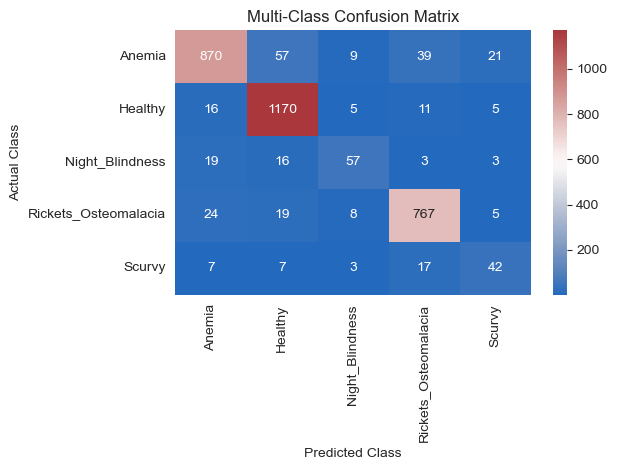

In [28]:
model_1 = "LogisticRegression"
Title_Lr = title + " " + model_1.upper()
clf_Lr = cross_val_predict(Lr, X_train_pro, y_train, cv= 3)
print(f"{Title_Lr:*^100} ")
print(classification_report(y_true=y_train,y_pred=clf_Lr,target_names=y_classes))
cm_Lr = confusion_matrix(y_true=y_train, y_pred=clf_Lr)


sns.heatmap(
    cm_Lr, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

**************************CLASSIFICATION REPORT FOR DECISIONTREECLASSIFIER**************************
                      precision    recall  f1-score   support

              Anemia       0.99      0.99      0.99       996
             Healthy       0.99      0.99      0.99      1207
     Night_Blindness       0.92      0.94      0.93        98
Rickets_Osteomalacia       1.00      1.00      1.00       823
              Scurvy       0.99      0.89      0.94        76

            accuracy                           0.99      3200
           macro avg       0.98      0.96      0.97      3200
        weighted avg       0.99      0.99      0.99      3200



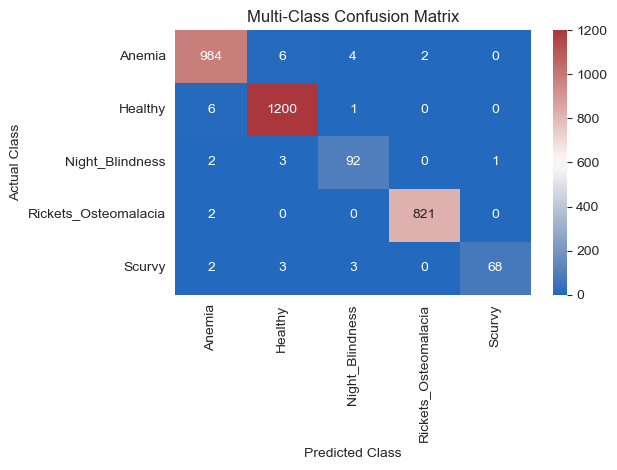

In [29]:
clf_tr = cross_val_predict(tr, X_train_pro, y_train, cv= 3)
model_2 = "DecisionTreeClassifier"
Title_tr = title + " " + model_2.upper()
cm_tr = confusion_matrix(y_train, clf_tr)
print(f"{Title_tr:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_tr,target_names=y_classes))
cm_tr = confusion_matrix(y_true=y_train, y_pred=clf_tr)

sns.heatmap(
    cm_tr, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


***************************CLASSIFICATION REPORT FOR KNEIGHBORSCLASSIFIER***************************
                      precision    recall  f1-score   support

              Anemia       0.74      0.69      0.71       996
             Healthy       0.76      0.92      0.83      1207
     Night_Blindness       0.41      0.13      0.20        98
Rickets_Osteomalacia       0.75      0.67      0.71       823
              Scurvy       0.43      0.25      0.32        76

            accuracy                           0.74      3200
           macro avg       0.62      0.53      0.55      3200
        weighted avg       0.73      0.74      0.73      3200



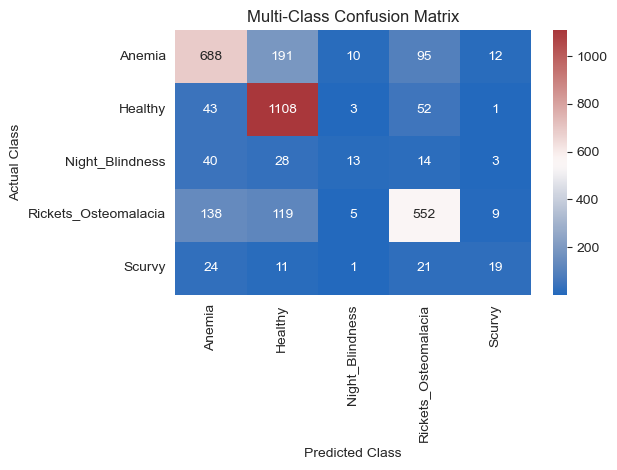

In [30]:
model_3 = "KNeighborsClassifier"
Title_knn = title + " " + model_3.upper()

clf_knn = cross_val_predict(knn, X_train_pro, y_train, cv= 3)
print(f"{Title_knn:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_knn,target_names=y_classes))
cm_knn = confusion_matrix(y_true=y_train, y_pred=clf_knn)

sns.heatmap(
    cm_knn, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

**************************CLASSIFICATION REPORT FOR RANDOMFORESTCLASSIFIER**************************
                      precision    recall  f1-score   support

              Anemia       0.95      1.00      0.97       996
             Healthy       0.99      0.99      0.99      1207
     Night_Blindness       0.96      0.72      0.83        98
Rickets_Osteomalacia       0.97      0.99      0.98       823
              Scurvy       1.00      0.47      0.64        76

            accuracy                           0.97      3200
           macro avg       0.97      0.84      0.88      3200
        weighted avg       0.97      0.97      0.97      3200



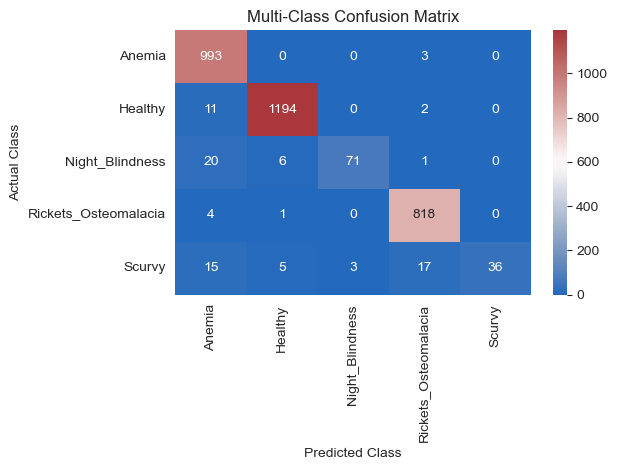

In [31]:
clf_rc = cross_val_predict(rc, X_train_pro, y_train, cv= 3)
model_4 = "RandomForestClassifier"
Title_rc = title + " " + model_4.upper()
cm_rc = confusion_matrix(y_train, clf_rc)
print(f"{Title_rc:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_rc,target_names=y_classes))
cm_rc = confusion_matrix(y_true=y_train, y_pred=clf_rc)

sns.heatmap(
    cm_rc, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


In [32]:
model = make_pipeline(preprocess, tr)
model.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('pipeline-1',
                                    Pipeline(steps=[('onehotencoder',
                                                     OneHotEncoder(sparse_output=False)),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x000001B766613CB0>),
                                   ('pipeline-2',
                                    Pipeline(steps=[('standardscaler',
                                                     StandardScaler())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x000001B7677691D0>)])),
  ('decisiontreeclassifier', DecisionTreeClassifier(random_state=17))],
 'transform_input': None,
 'verbose': False,
 'columntransformer': Column

In [33]:
param = {
    'decisiontreeclassifier__criterion': ['gini', 'entropy'],
    'decisiontreeclassifier__max_depth': [None, 3, 5, 7, 10],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 4],
    'decisiontreeclassifier__class_weight': [None, 'balanced'] # Added for single-label class balance
}
grid = GridSearchCV(estimator=model, param_grid=param, cv = 3, scoring='accuracy')

In [34]:
grid

,estimator,Pipeline(step...m_state=17))])
,param_grid,"{'decisiontreeclassifier__class_weight': [None, 'balanced'], 'decisiontreeclassifier__criterion': ['gini', 'entropy'], 'decisiontreeclassifier__max_depth': [None, 3, ...], 'decisiontreeclassifier__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"


In [35]:
grid.fit(X_train_pro, y_train)

,estimator,Pipeline(step...m_state=17))])
,param_grid,"{'decisiontreeclassifier__class_weight': [None, 'balanced'], 'decisiontreeclassifier__criterion': ['gini', 'entropy'], 'decisiontreeclassifier__max_depth': [None, 3, ...], 'decisiontreeclassifier__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"


In [36]:
pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending= False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__class_weight,param_decisiontreeclassifier__criterion,param_decisiontreeclassifier__max_depth,param_decisiontreeclassifier__min_samples_leaf,param_decisiontreeclassifier__min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
138,0.025710,0.001040,0.002669,0.000451,balanced,entropy,None,2,2,{'decisiontreeclassifier__class_weight': 'bala...,0.996251,0.990628,0.995310,0.994063,0.002459,1
174,0.024515,0.003121,0.002956,0.000515,balanced,entropy,10,2,2,{'decisiontreeclassifier__class_weight': 'bala...,0.996251,0.990628,0.995310,0.994063,0.002459,1
127,0.032933,0.006013,0.003880,0.001381,balanced,gini,10,1,5,{'decisiontreeclassifier__class_weight': 'bala...,0.995314,0.989691,0.996248,0.993751,0.002896,3
171,0.032304,0.000910,0.002844,0.000064,balanced,entropy,10,1,2,{'decisiontreeclassifier__class_weight': 'bala...,0.996251,0.988754,0.996248,0.993751,0.003534,3
91,0.027279,0.000724,0.003952,0.001086,balanced,gini,None,1,5,{'decisiontreeclassifier__class_weight': 'bala...,0.995314,0.989691,0.996248,0.993751,0.002896,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,0.013009,0.001495,0.003490,0.001061,balanced,gini,3,2,2,{'decisiontreeclassifier__class_weight': 'bala...,0.668229,0.668229,0.666979,0.667812,0.000589,172
103,0.012011,0.000673,0.002561,0.000060,balanced,gini,3,2,5,{'decisiontreeclassifier__class_weight': 'bala...,0.668229,0.668229,0.666979,0.667812,0.000589,172
104,0.011667,0.000466,0.004093,0.001258,balanced,gini,3,2,10,{'decisiontreeclassifier__class_weight': 'bala...,0.668229,0.668229,0.666979,0.667812,0.000589,172
107,0.011766,0.000286,0.002186,0.000204,balanced,gini,3,4,10,{'decisiontreeclassifier__class_weight': 'bala...,0.668229,0.668229,0.666979,0.667812,0.000589,172


In [37]:
finished_model = grid.best_estimator_

In [38]:
finished_model.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
pred = finished_model.predict(X_test)

In [40]:
count = 0
predicted = (pred == y_test)
for i in predicted:
    if not i:
        count += 1

In [41]:
if all(predicted):
    print('Yes')
else:
    if count == 1:
        print(f'{count} is False')
    else:
        print(f"{count} are False")
    

3 are False


In [42]:
import joblib

# 1. Saving the final trained pipeline model
joblib.dump(finished_model, 'model.pkl')


# Target classes are: ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
joblib.dump(y_classes, 'classes.pkl')

print("Model assets successfully exported for deployment!")


Model assets successfully exported for deployment!
